### Notebook 2: ARIMA Modeling (Classical Time Series)

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle
import warnings
warnings.filterwarnings('ignore')

### Load Cleaned Data

In [35]:
data = pd.read_csv("../data/processed/Austin_Weather_Cleaned.csv")
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)
data = data.sort_index()

print(f"Data loaded successfully!")
print(f"Shape: {data.shape}")
print(f"Date Range: {data.index[0].date()} to {data.index[-1].date()}")

# Focus on high temperature (main target for heat wave prediction)
temp_series = data['TempHighF'].copy()

print(f"\nTemperature Series:")
print(f"  • Length: {len(temp_series)}")
print(f"  • Mean: {temp_series.mean():.2f}°F")
print(f"  • Std Dev: {temp_series.std():.2f}°F")
print(f"  • Min: {temp_series.min():.2f}°F")
print(f"  • Max: {temp_series.max():.2f}°F")

Data loaded successfully!
Shape: (10354, 12)
Date Range: 1999-01-01 to 2023-09-26

Temperature Series:
  • Length: 10354
  • Mean: 80.35°F
  • Std Dev: 14.77°F
  • Min: 22.60°F
  • Max: 110.40°F


### Stationarity Testing

In [36]:
def check_stationarity(timeseries, name="Series"):
    """Perform Augmented Dickey-Fuller test for stationarity"""
    result = adfuller(timeseries.dropna())
    
    print(f"\n{name}:")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value: {result[1]:.4f}")
    print(f"  Critical Values:")
    for key, value in result[4].items():
        print(f"    {key}: {value:.4f}")
    
    if result[1] <= 0.05:
        print(f"   Series is STATIONARY (p-value < 0.05)")
        print(f"   No differencing needed")
        return True, 0
    else:
        print(f"   Series is NON-STATIONARY (p-value >= 0.05)")
        print(f"   Differencing required")
        return False, None

# Test original series
is_stationary, d_order = check_stationarity(temp_series, "Original Temperature Series")

# If non-stationary, test differenced series
if not is_stationary:
    temp_diff1 = temp_series.diff().dropna()
    is_stationary_diff1, _ = check_stationarity(temp_diff1, "First Differenced Series")
    
    if is_stationary_diff1:
        d_order = 1
        print("\n Conclusion: Use d=1 (first difference)")
    else:
        temp_diff2 = temp_diff1.diff().dropna()
        check_stationarity(temp_diff2, "Second Differenced Series")
        d_order = 2
        print("\n Conclusion: Use d=2 (second difference)")
else:
    d_order = 0
    print("\n Conclusion: Use d=0 (no differencing)")


Original Temperature Series:
  ADF Statistic: -5.9169
  p-value: 0.0000
  Critical Values:
    1%: -3.4310
    5%: -2.8618
    10%: -2.5669
   Series is STATIONARY (p-value < 0.05)
   No differencing needed

 Conclusion: Use d=0 (no differencing)


### ACF and PACF Analysis


Generating ACF and PACF plots...
   ACF (Autocorrelation): Use to determine q (MA order)
   PACF (Partial Autocorrelation): Use to determine p (AR order)
✓ Saved: acf_pacf_plots.png


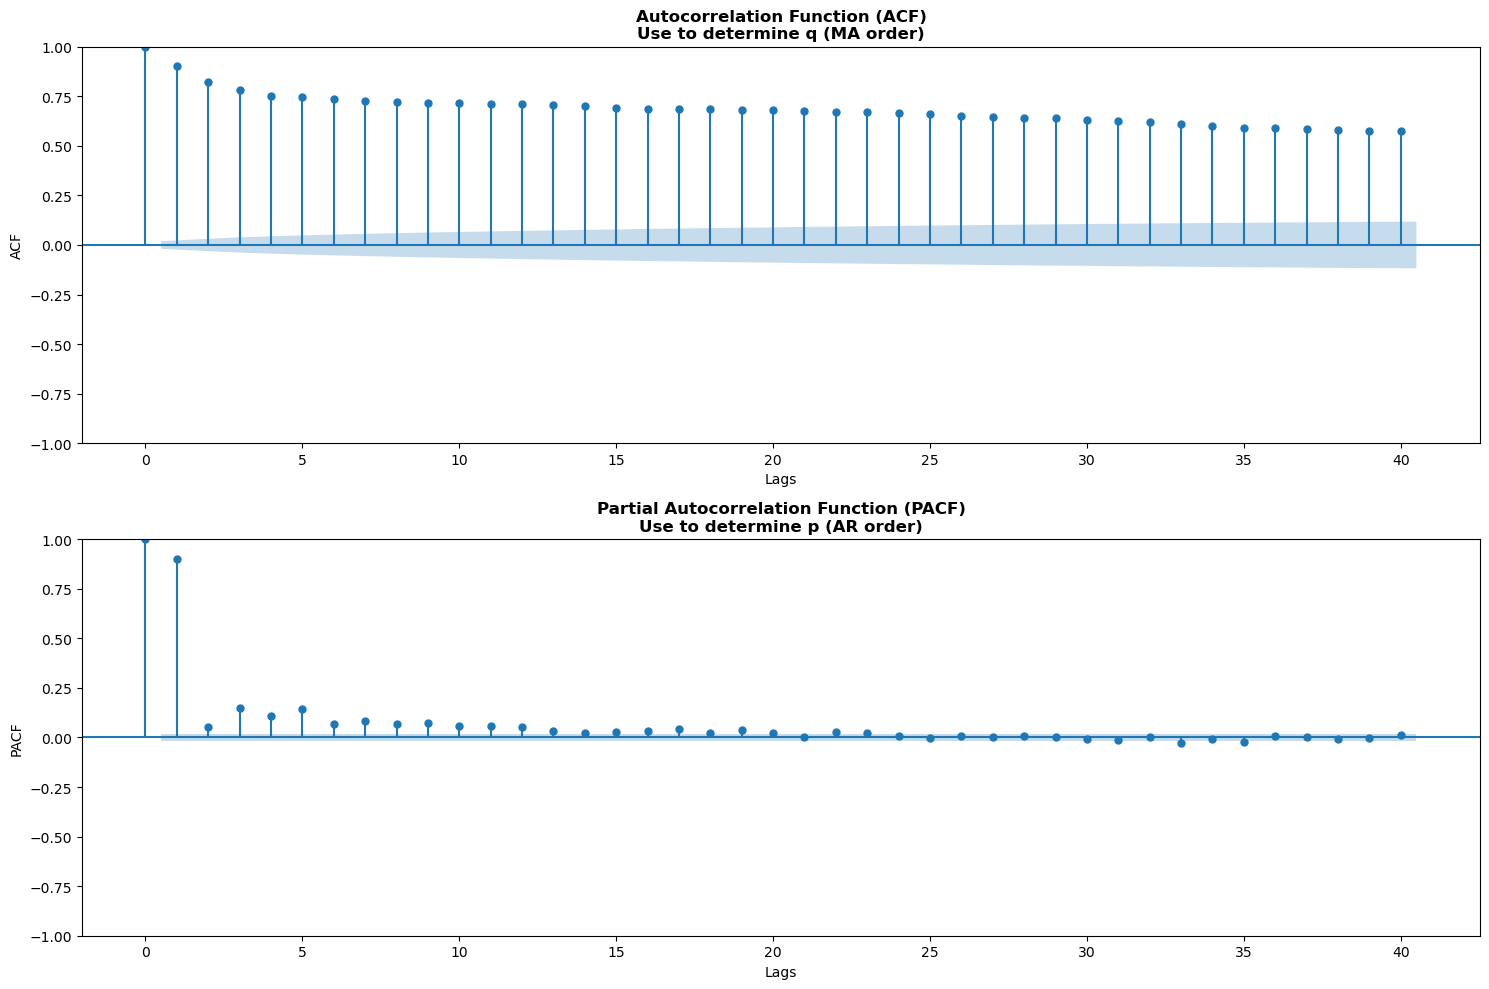


Reading ACF/PACF Guidelines:
  • PACF: Count significant lags (outside blue shaded area) → suggests p
  • ACF: Look for exponential decay or cutoff → suggests q

For daily temperature data:
  • Strong weekly patterns → try p around 7
  • Usually small MA component → try q=0,1,2

→ Selected ARIMA Parameters: (1, 0, 1)
  • p=1: Autoregressive order (weekly patterns)
  • d=0: Differencing order (stationarity)
  • q=1: Moving average order


In [37]:
# Prepare series for ACF/PACF analysis
if d_order == 1:
    analysis_series = temp_series.diff().dropna()
elif d_order == 2:
    analysis_series = temp_series.diff().diff().dropna()
else:
    analysis_series = temp_series

print("\nGenerating ACF and PACF plots...")
print("   ACF (Autocorrelation): Use to determine q (MA order)")
print("   PACF (Partial Autocorrelation): Use to determine p (AR order)")

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# ACF plot
plot_acf(analysis_series, lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)\nUse to determine q (MA order)', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('ACF')

# PACF plot
plot_pacf(analysis_series, lags=40, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)\nUse to determine p (AR order)', 
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('PACF')

plt.tight_layout()
plt.savefig('../reports/figures/acf_pacf_plots.png', dpi=300, bbox_inches='tight')
print("✓ Saved: acf_pacf_plots.png")
plt.show()

print("\nReading ACF/PACF Guidelines:")
print("  • PACF: Count significant lags (outside blue shaded area) → suggests p")
print("  • ACF: Look for exponential decay or cutoff → suggests q")
print("\nFor daily temperature data:")
print("  • Strong weekly patterns → try p around 7")
print("  • Usually small MA component → try q=0,1,2")

# Parameter selection based on temperature characteristics
p_value = 1  # AR order - captures weekly patterns
q_value = 1  # MA order - small moving average component


print(f"\n→ Selected ARIMA Parameters: ({p_value}, {d_order}, {q_value})")
print(f"  • p={p_value}: Autoregressive order (weekly patterns)")
print(f"  • d={d_order}: Differencing order (stationarity)")
print(f"  • q={q_value}: Moving average order")

### Train / Test Split

In [38]:
# 80/20 split
train_size = int(len(temp_series) * 0.8)
train = temp_series[:train_size]
test = temp_series[train_size:]

print(f"\nTraining Set:")
print(f"   Size: {len(train)} observations")
print(f"   Date Range: {train.index[0].date()} to {train.index[-1].date()}")
print(f"   Mean Temp: {train.mean():.2f}°F")

print(f"\nTest Set:")
print(f"   Size: {len(test)} observations")
print(f"   Date Range: {test.index[0].date()} to {test.index[-1].date()}")
print(f"   Mean Temp: {test.mean():.2f}°F")


Training Set:
   Size: 8283 observations
   Date Range: 1999-01-01 to 2018-01-24
   Mean Temp: 80.05°F

Test Set:
   Size: 2071 observations
   Date Range: 2018-01-25 to 2023-09-26
   Mean Temp: 81.57°F


### Fit ARIMA Model

In [39]:
print(f"\nFitting ARIMA({p_value}, {d_order}, {q_value}) model...")
print("This may take a few moments...")

# Fit ARIMA
arima_model = ARIMA(train, order=(p_value, d_order, q_value))
arima_fitted = arima_model.fit()

print("Model fitting complete!")

# Print model summary
print("\n" + "="*70)
print("MODEL SUMMARY")
print("="*70)
print(arima_fitted.summary())


Fitting ARIMA(1, 0, 1) model...
This may take a few moments...
Model fitting complete!

MODEL SUMMARY
                               SARIMAX Results                                
Dep. Variable:              TempHighF   No. Observations:                 8283
Model:                 ARIMA(1, 0, 1)   Log Likelihood              -26868.926
Date:                Fri, 14 Nov 2025   AIC                          53745.852
Time:                        19:05:15   BIC                          53773.940
Sample:                             0   HQIC                         53755.449
                               - 8283                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         80.0443      1.056     75.801      0.000      77.975      82.114
ar.L1          0.9202      0

### Make Predictions

In [40]:
# In-sample predictions (training set)
arima_train_pred = arima_fitted.fittedvalues

# Out-of-sample forecast (test set) - ROLLING APPROACH
print("\n🔄 Generating rolling forecasts on test set...")
print("   This ensures realistic one-step-ahead predictions")

arima_test_pred = []
history = train.copy()
fitted_temp = arima_fitted  # Start with trained model

for i in range(len(test)):
    # Refit every 30 days to incorporate recent observations
    if i % 30 == 0:
        model_temp = ARIMA(history, order=(1, 0, 1))
        fitted_temp = model_temp.fit(method_kwargs={"warn_convergence": False})
        if i > 0:
            print(f"   Refitted at observation {i}/{len(test)}")
    
    # Forecast only the next day
    forecast = fitted_temp.forecast(steps=1)
    arima_test_pred.append(forecast.values[0])
    
    # Add actual observation to history for next iteration
    history = pd.concat([history, test.iloc[i:i+1]])

# Convert to Series with proper index
arima_test_pred = pd.Series(arima_test_pred, index=test.index)

print(f"✓ Training predictions generated: {len(arima_train_pred)} values")
print(f"✓ Test predictions generated: {len(arima_test_pred)} values")


🔄 Generating rolling forecasts on test set...
   This ensures realistic one-step-ahead predictions
   Refitted at observation 30/2071
   Refitted at observation 60/2071
   Refitted at observation 90/2071
   Refitted at observation 120/2071
   Refitted at observation 150/2071
   Refitted at observation 180/2071
   Refitted at observation 210/2071
   Refitted at observation 240/2071
   Refitted at observation 270/2071
   Refitted at observation 300/2071
   Refitted at observation 330/2071
   Refitted at observation 360/2071
   Refitted at observation 390/2071
   Refitted at observation 420/2071
   Refitted at observation 450/2071
   Refitted at observation 480/2071
   Refitted at observation 510/2071
   Refitted at observation 540/2071
   Refitted at observation 570/2071
   Refitted at observation 600/2071
   Refitted at observation 630/2071
   Refitted at observation 660/2071
   Refitted at observation 690/2071
   Refitted at observation 720/2071
   Refitted at observation 750/2071
   

### Evaluate Model Performance

In [41]:
# Training metrics (skip first p values due to AR component)
train_actual = train.iloc[p_value:]
train_pred_aligned = arima_train_pred.iloc[p_value:]

train_mae = mean_absolute_error(train_actual, train_pred_aligned)
train_rmse = np.sqrt(mean_squared_error(train_actual, train_pred_aligned))
train_r2 = r2_score(train_actual, train_pred_aligned)

# Test metrics
test_mae = mean_absolute_error(test, arima_test_pred)
test_rmse = np.sqrt(mean_squared_error(test, arima_test_pred))
test_r2 = r2_score(test, arima_test_pred)

print("\nPerformance Metrics:")
print("\nTraining Set:")
print(f"  MAE:  {train_mae:.2f}°F")
print(f"  RMSE: {train_rmse:.2f}°F")
print(f"  R²:   {train_r2:.3f}")

print("\nTest Set:")
print(f"  MAE:  {test_mae:.2f}°F")
print(f"  RMSE: {test_rmse:.2f}°F")
print(f"  R²:   {test_r2:.3f}")

# Interpretation
print("\nInterpretation:")
if test_mae < 5:
    print("  Excellent: Average error < 5°F")
elif test_mae < 7:
    print("  Good: Average error < 7°F")
elif test_mae < 10:
    print("  Fair: Average error < 10°F")
else:
    print("  Poor: Average error >= 10°F, consider tuning")


Performance Metrics:

Training Set:
  MAE:  4.22°F
  RMSE: 6.20°F
  R²:   0.820

Test Set:
  MAE:  8.17°F
  RMSE: 10.96°F
  R²:   0.483

Interpretation:
  Fair: Average error < 10°F


### Diagnostic Plots 


Generating diagnostic plots...
Saved: arima_diagnostics.png


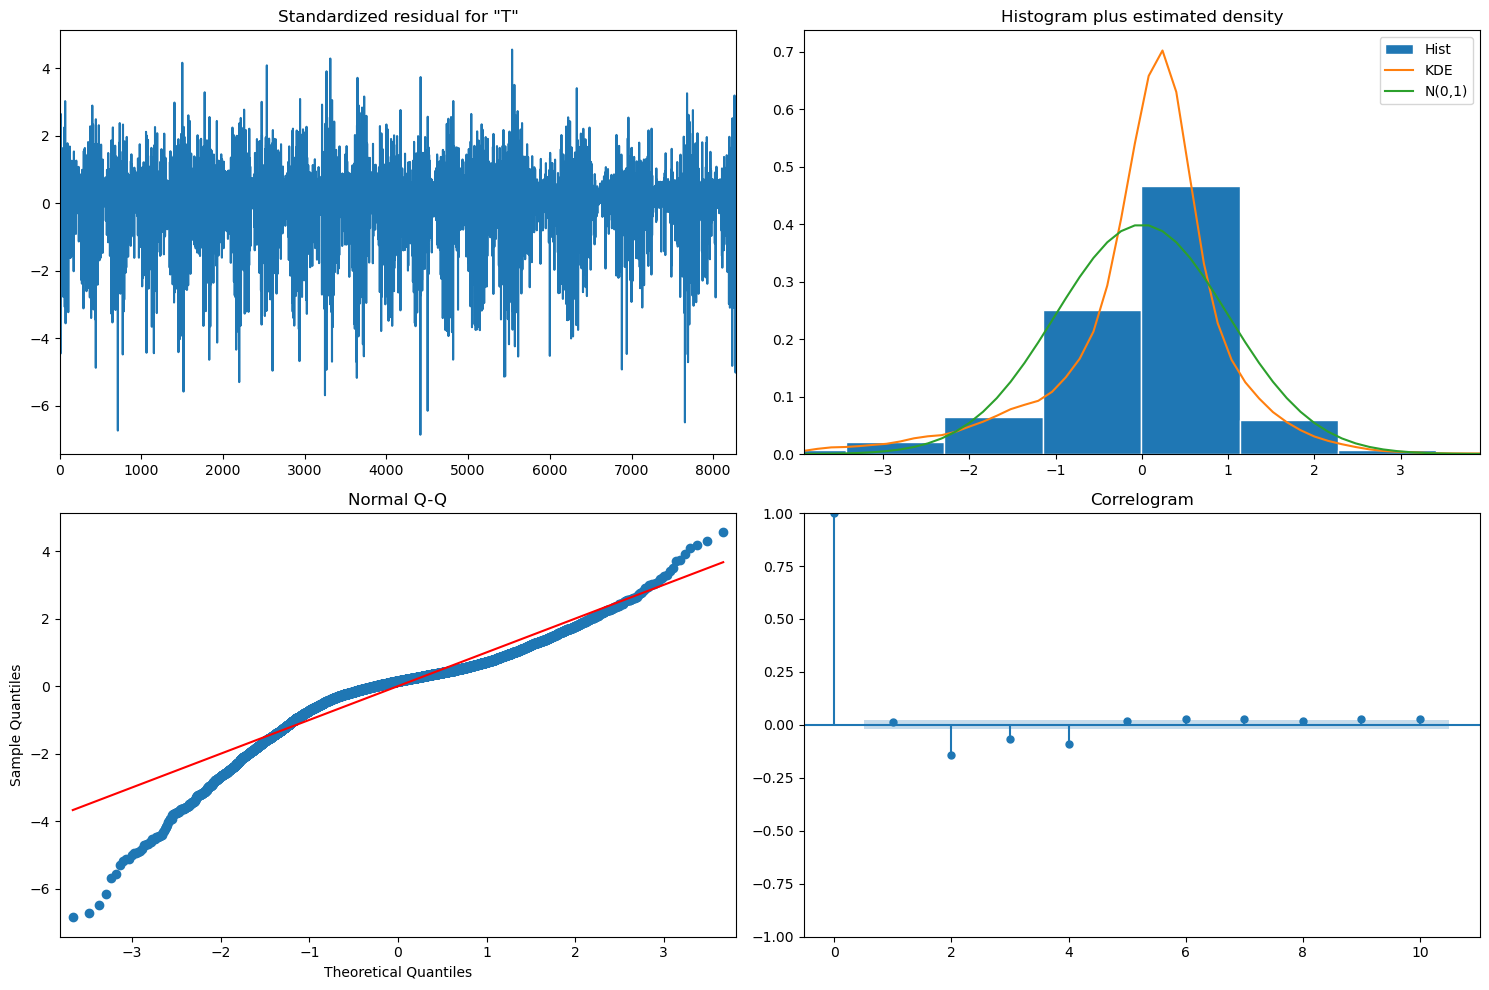


Diagnostic Check Guidelines:
  Top-left: Residuals should look random (no pattern)
  Top-right: Histogram should be roughly normal
  Bottom-left: Q-Q plot should follow red line
  Bottom-right: Correlogram should be within blue bands


In [42]:
print("\nGenerating diagnostic plots...")

# Residual diagnostics
fig = arima_fitted.plot_diagnostics(figsize=(15, 10))
plt.tight_layout()
plt.savefig('../reports/figures/arima_diagnostics.png', dpi=300, bbox_inches='tight')
print("Saved: arima_diagnostics.png")
plt.show()

print("\nDiagnostic Check Guidelines:")
print("  Top-left: Residuals should look random (no pattern)")
print("  Top-right: Histogram should be roughly normal")
print("  Bottom-left: Q-Q plot should follow red line")
print("  Bottom-right: Correlogram should be within blue bands")

### Visualize Predictions

Saved: arima_predictions.png


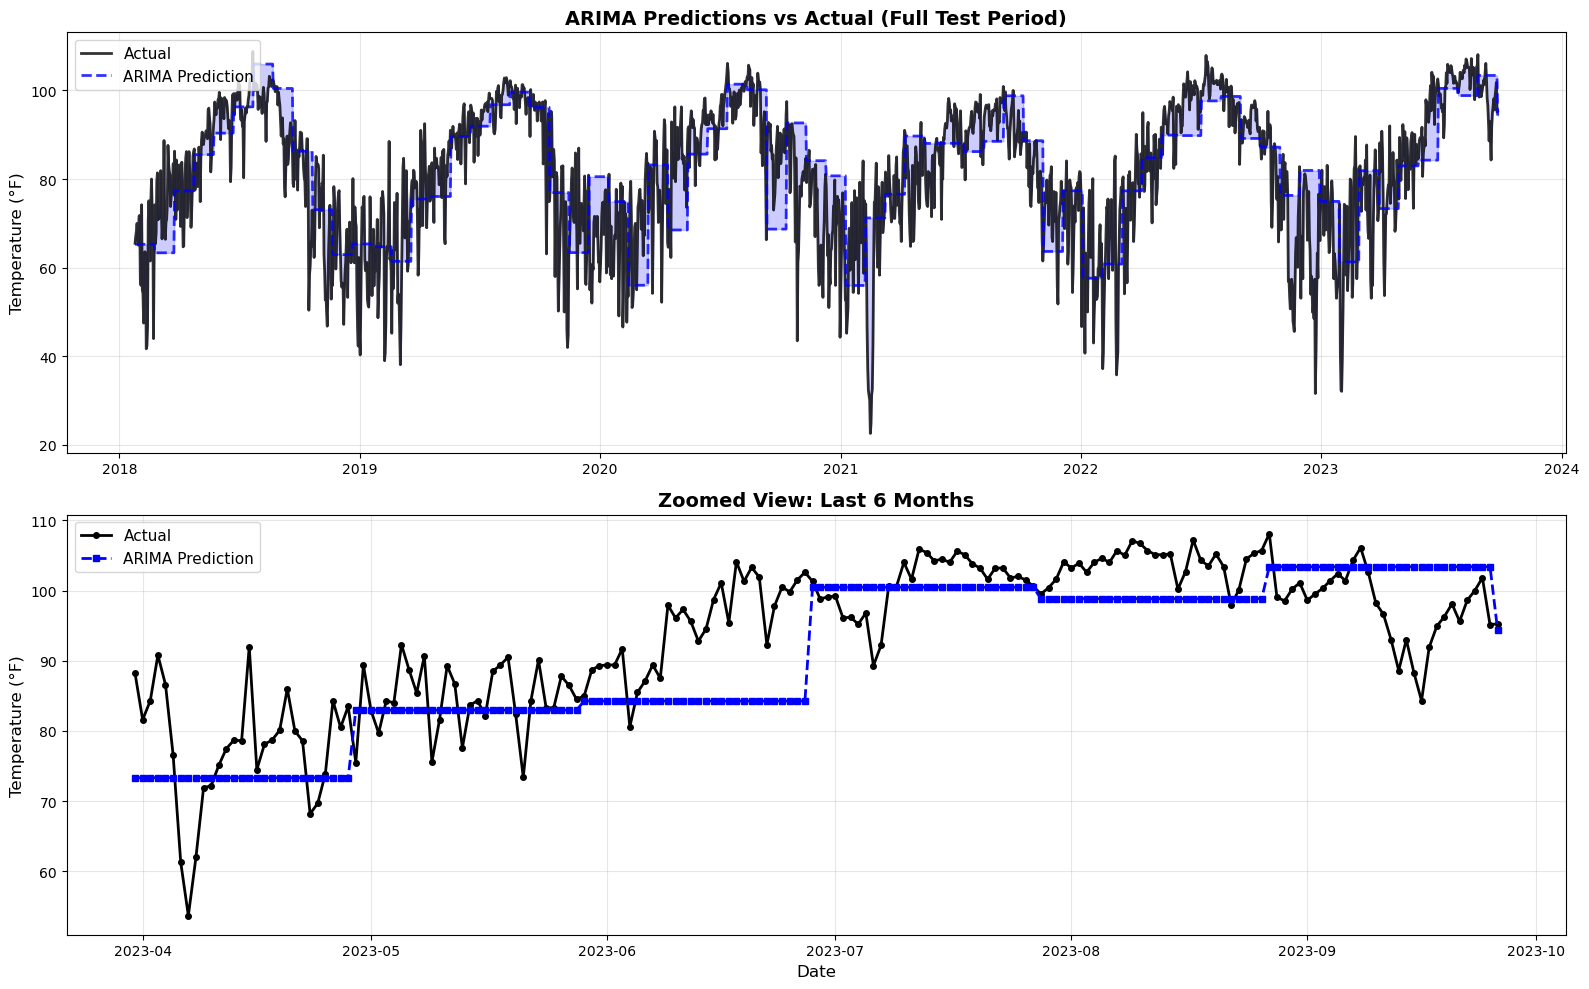

Saved: arima_error_distribution.png


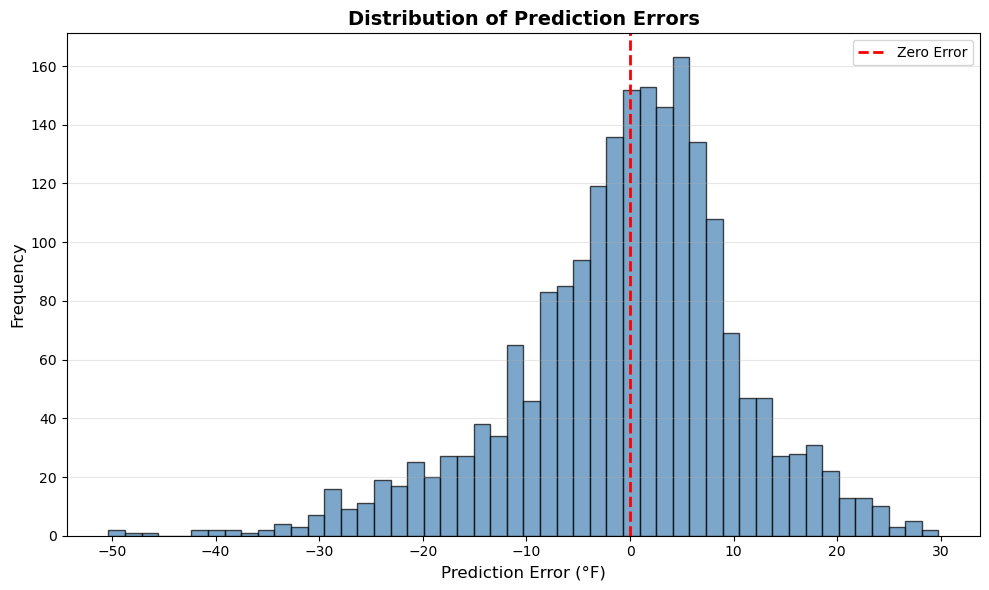

In [43]:
# Plot 1: Full time series with predictions
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Full test period
axes[0].plot(test.index, test, label='Actual', color='black', linewidth=2, alpha=0.8)
axes[0].plot(arima_test_pred.index, arima_test_pred, label='ARIMA Prediction', 
             color='blue', linestyle='--', linewidth=2, alpha=0.8)
axes[0].fill_between(test.index, test, arima_test_pred, alpha=0.2, color='blue')
axes[0].set_ylabel('Temperature (°F)', fontsize=12)
axes[0].set_title('ARIMA Predictions vs Actual (Full Test Period)', 
                  fontsize=14, fontweight='bold')
axes[0].legend(loc='upper left', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Zoomed view (last 180 days)
zoom_start = test.index[-180] if len(test) >= 180 else test.index[0]
zoom_test = test.loc[zoom_start:]
zoom_pred = arima_test_pred.loc[zoom_start:]

axes[1].plot(zoom_test.index, zoom_test, label='Actual', 
             color='black', linewidth=2, marker='o', markersize=4)
axes[1].plot(zoom_pred.index, zoom_pred, label='ARIMA Prediction', 
             color='blue', linestyle='--', linewidth=2, marker='s', markersize=4)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Temperature (°F)', fontsize=12)
axes[1].set_title('Zoomed View: Last 6 Months', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper left', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/arima_predictions.png', dpi=300, bbox_inches='tight')
print("Saved: arima_predictions.png")
plt.show()

# Plot 2: Error distribution
fig, ax = plt.subplots(figsize=(10, 6))
errors = test - arima_test_pred
ax.hist(errors, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax.set_xlabel('Prediction Error (°F)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/arima_error_distribution.png', dpi=300, bbox_inches='tight')
print("Saved: arima_error_distribution.png")
plt.show()


### Save Model and Predictions

In [44]:
# Save fitted model
model_path = '../models/arima_fitted.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(arima_fitted, f)
print(f"Model saved: {model_path}")

# Save predictions
predictions_df = pd.DataFrame({
    'Date': test.index,
    'Actual': test.values,
    'ARIMA_Prediction': arima_test_pred.values,
    'Error': (test - arima_test_pred).values,
    'Absolute_Error': np.abs(test - arima_test_pred).values
})

pred_path = '../reports/predictions/arima_predictions.csv'
predictions_df.to_csv(pred_path, index=False)
print(f"Predictions saved: {pred_path}")

# Save metrics summary
metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Training': [train_mae, train_rmse, train_r2],
    'Test': [test_mae, test_rmse, test_r2]
})

metrics_path = '../reports/predictions/arima_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)
print(f"Metrics saved: {metrics_path}")

Model saved: ../models/arima_fitted.pkl
Predictions saved: ../reports/predictions/arima_predictions.csv
Metrics saved: ../reports/predictions/arima_metrics.csv
